# Examine ALE Plots 

- Observation: The ALE curve for $x_2$ for $f(x) = x_1 + x_1  x_2$ looks like a quadratic when $x_1,x_2$ are highly correlated.
    - No, rather we might expect it as the "average" in the dataset of $x_2$ as $x_3$ varies, that is, the ALE curve $f_{ALE,j}(x_2)=\mathbb{E}[X_1\mid X_2=x_2]x_2$. Since we can roughly estimate $\mathbb{E}[X_1\mid X_2=x_2]=x_2$ due to the high correlation, we would expect to see a quadratic curve.
    - This is the *correct inference*, as we should expect that as $x_2$ increases, the value of $f$ should increase due to both $x_2$ getting larger, and $x_1$ getting larger *because it tends to be larger with $x_2$.

- Observation: It seems like the main effects are somehow also capturing some interaction effects. For example, with highly correlated $X_1,X_2$, we have $f(x)=x_1+x_2+x_1x_2$ producing $ALE_{j,M}\approx ALE^Q_{j,T}$. Now that we observe the above example, this makes sense -- the ALE plot takes into account the interaction behavior and therefore the main effect does too.

- Observation: The VIM changes as the number of bins varies.

In [13]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# from algorithms.fast_ale import (
#     ale_1d_fast as ale_1d,
#     ale_2d_fast as ale_2d,
#     ale_global_main_fast as ale_global_main,
#     ale_connected_total_fast as ale_connected_total,
#     ale_connected_modified_total_fast as ale_connected_modified_total,
#     ale_quantile_total_fast as ale_quantile_total
# )

from algorithms.shared import (
    bin_selection
)
from algorithms.ale import (
    ale_1d,
    ale_2d,
)
from algorithms.ale_vim import (
    ale_global_main,
    ale_connected_total,
    ale_quantile_total
)
from utils import replicate_ale_vims

In [14]:
# generate data
def generate_2d_data(n, sigma=0.05):
    Z = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    epsilon = np.random.normal(0, sigma, n)
    X1 = Z
    X2 = Z + epsilon

    return np.vstack([X1, X2]).T

def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data(n, sigma=0.05):
    Z = np.random.uniform(1, 2, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    epsilon_3 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2
    X3 = Z + epsilon_3
    return np.vstack([X1, X2, X3]).T

def generate_mixed_data(n, num_categories=3):
    x1 = np.random.randint(0, num_categories, n)
    x2 = np.random.uniform(0, 1, n)
    return np.vstack([x1, x2]).T

In [15]:
# Setting 1: normal DGP
# def f(x):
#     return x[:, 0] + x[:, 1] + x[:, 0] * x[:, 1]
# n = 100
# rho = 0.5
# bins = bin_selection(n)
# dgp = lambda n: generate_2d_data_normal(n, rho=rho)

# Setting 2: uniform DGP
def f(x):
    return x[:, 0] + x[:, 1] + x[:, 0] * x[:, 1]
n = 10000
sigma = 0.1
bins = bin_selection(n)
dgp = lambda n: generate_2d_data(n, sigma=sigma)

# Setting 3: mixed categorical and continuous DGP
# def f(x):
#     return x[:, 0] + x[:, 1] + x[:, 0] * x[:, 1] 
# n = 1600
# bins = bin_selection(n)
# dgp = lambda n: generate_mixed_data(n, num_categories=4)

X = dgp(n)
y = f(X)

In [16]:
vim_mains, vim_connected, vim_quantile = replicate_ale_vims(dgp, f, 2, n=n, bins=bins, replications=10, categorical=False)

Replication 1, Variable 1: VIM Main: 1.1576311107800723, VIM Connected: 1.235994750639567, VIM Quantile: 0.758880154604677
Replication 1, Variable 2: VIM Main: 1.1620750697960094, VIM Connected: 1.2740399035726897, VIM Quantile: 0.8788157408435929
Replication 2, Variable 1: VIM Main: 1.1677246134976045, VIM Connected: 1.2466540771328378, VIM Quantile: 1.5609307333735383
Replication 2, Variable 2: VIM Main: 1.1833084169172654, VIM Connected: 1.3141306950180445, VIM Quantile: 2.5571284446663807
Replication 3, Variable 1: VIM Main: 1.1654926348025412, VIM Connected: 1.2448367424842708, VIM Quantile: 1.1036275587429363
Replication 3, Variable 2: VIM Main: 1.171114638692331, VIM Connected: 1.2824830246276657, VIM Quantile: 1.2762840534988917
Replication 4, Variable 1: VIM Main: 1.1819284534740406, VIM Connected: 1.2597500582746788, VIM Quantile: 1.3202806581308615
Replication 4, Variable 2: VIM Main: 1.1845937563599358, VIM Connected: 1.30590598028646, VIM Quantile: 1.3949314719218366
Repli

In [17]:
# # plot heatmap of vim_1_mains and vim_2_mains
# plt.figure(figsize=(10, 5))
# plt.hist2d(vim_mains[:, 0], vim_mains[:, 1], bins=20, cmap='Blues')
# plt.colorbar(label='Frequency')
# plt.xlabel('VIM 1 Main Importance')
# plt.ylabel('VIM 2 Main Importance')
# plt.title('Heatmap of VIM 1 and VIM 2 Main Importance')
# plt.show()

In [18]:
# # plot heatmap of vim_1_quantile and vim_2_quantile
# plt.figure(figsize=(10, 5))
# plt.hist2d(vim_quantiles[:, 0], vim_quantiles[:, 1], bins=20, cmap='Blues')
# plt.colorbar(label='Frequency')
# plt.xlabel('VIM 1 Quantile Importance')
# plt.ylabel('VIM 2 Quantile Importance')
# plt.title('Heatmap of VIM 1 and VIM 2 Total Quantile Importance')
# plt.show()

In [19]:
# # plot heatmap of vim_1_connected and vim_2_connected
# plt.figure(figsize=(10, 5))
# plt.hist2d(vim_connected[:, 0], vim_connected[:, 1], bins=20, cmap='Blues')
# plt.colorbar(label='Frequency')
# plt.xlabel('VIM 1 Connected Importance')
# plt.ylabel('VIM 2 Connected Importance')
# plt.title('Heatmap of VIM 1 and VIM 2 Total Connected Importance')
# plt.show()

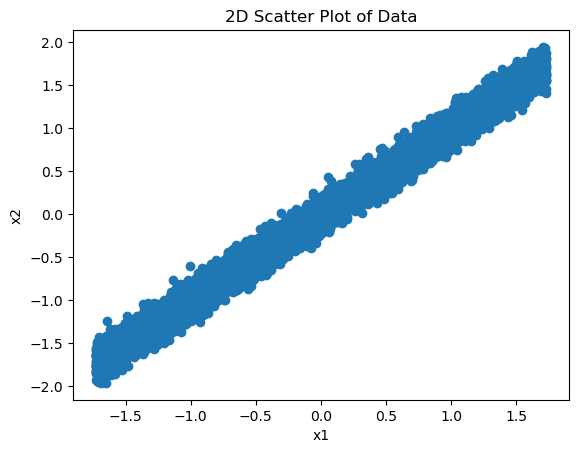

In [20]:
# 2d scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

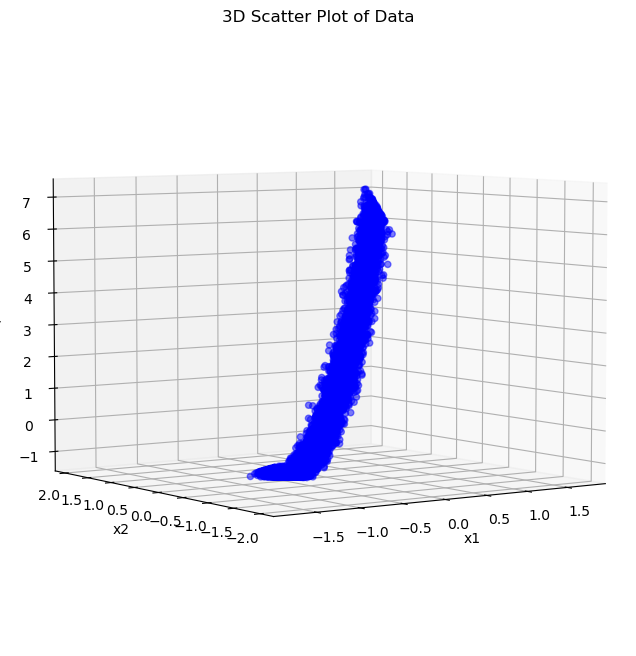

In [21]:
# 3d scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(5, 235)
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatter Plot of Data')
plt.show()

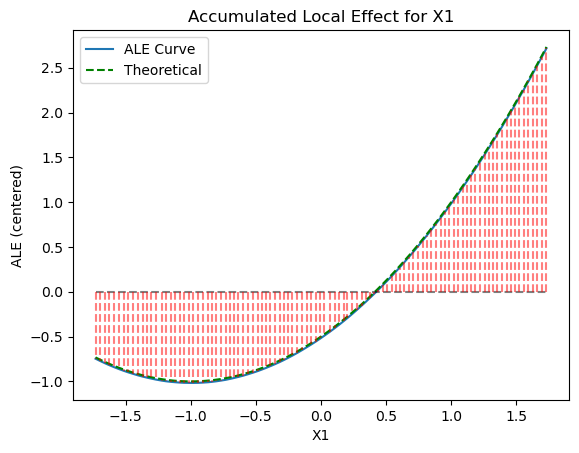

In [22]:
edges1, curve1 = ale_1d(f, X, 1, bins)
x_vals = np.linspace(edges1.min(), edges1.max(), 100)
theory = (1 / 2) * x_vals ** 2 + x_vals - (1 / 2)
plt.figure()
plt.plot(edges1, curve1, label='ALE Curve')
plt.plot(x_vals, theory, color='green', linestyle='--', label='Theoretical')
# draw horizontal line at y=0
plt.hlines(y=0, xmin=edges1.min(), xmax=edges1.max(), color='black', linestyle='--', alpha=0.5)
# draw vertical lines from 0 to the value of curve1 at each edge
plt.vlines(x=edges1, ymin=0, ymax=curve1, color='red', linestyle='--', alpha=0.5)
plt.xlabel("X1")
plt.ylabel("ALE (centered)")
plt.title("Accumulated Local Effect for X1")
plt.legend()
plt.show()

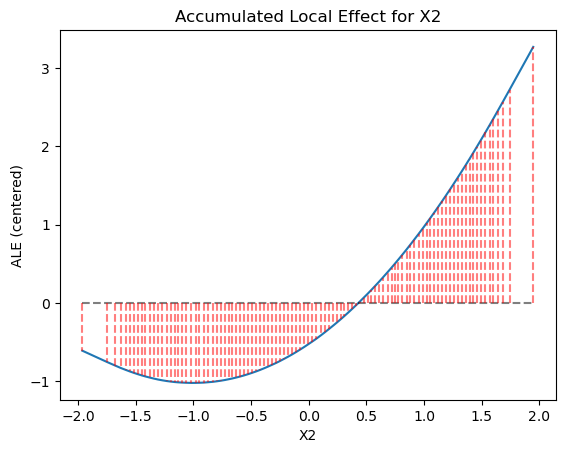

In [23]:
edges2, curve2 = ale_1d(f, X, 2, bins=bins)
x_vals = np.linspace(edges2.min(), edges2.max(), 100)
# theory = 6 / 5 + sigma ** 2
plt.plot(edges2, curve2, label='ALE Curve')
# plt.plot(x_vals, theory, color='green', linestyle='--', label='Theoretical')
# draw horizontal line at y=0
plt.hlines(y=0, xmin=edges2.min(), xmax=edges2.max(), color='black', linestyle='--', alpha=0.5)
# draw vertical lines from 0 to the value of curve2 at each edge
plt.vlines(x=edges2, ymin=0, ymax=curve2, color='red', linestyle='--', alpha=0.5)
plt.xlabel("X2")
plt.ylabel("ALE (centered)")
plt.title("Accumulated Local Effect for X2")
plt.show()

In [24]:
edges1_interaction, edges2_interaction, curve_interaction = ale_2d(f, X, 1, 2, bins=bins)
edges1_mesh, edges2_mesh = np.meshgrid(edges1_interaction, edges2_interaction)
plt.figure(figsize=(10, 8))
# plot heatmap
plt.pcolormesh(edges1_mesh, edges2_mesh, curve_interaction, shading='auto', cmap='viridis')
plt.colorbar(label='ALE (centered)')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Accumulated Local Effect for Interaction between X1 and X2")
plt.show()

ValueError: operands could not be broadcast together with shapes (100,100) (101,101) 